In [1]:
!pip install ultralytics

  Using cached setuptools-80.10.2-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 29.4 MB/s  0:00:00
   ---------------------------------------- 0.0/805.7 kB ? eta -:--:--
   ---------------------------------------- 805.7/805.7 kB 30.0 MB/s  0:00:00
   ---------------------------------------- 0.0/44.9 MB ? eta -:--:--
   ---------------------------------------  44.8/44.9 MB 293.1 MB/s eta 0:00:01
   ---------------------------------------  44.8/44.9 MB 293.1 MB/s eta 0:00:01
   ---------------------------------------- 44.9/44.9 MB 80.4 MB/s  0:00:00
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ------------------------- ------------- 73.4/113.8 MB 371.4 MB/s eta 0:00:01
   -------------------------------------  113.5/113.8 MB 358.3 MB/s eta 0:00:01
   -------------------------------------  113.5/113.8 MB 358.3 MB/s eta 0:00:01
   -------------------


0: 480x640 7 persons, 158.0ms
Speed: 3.9ms preprocess, 158.0ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)
Number of humans detected: 7


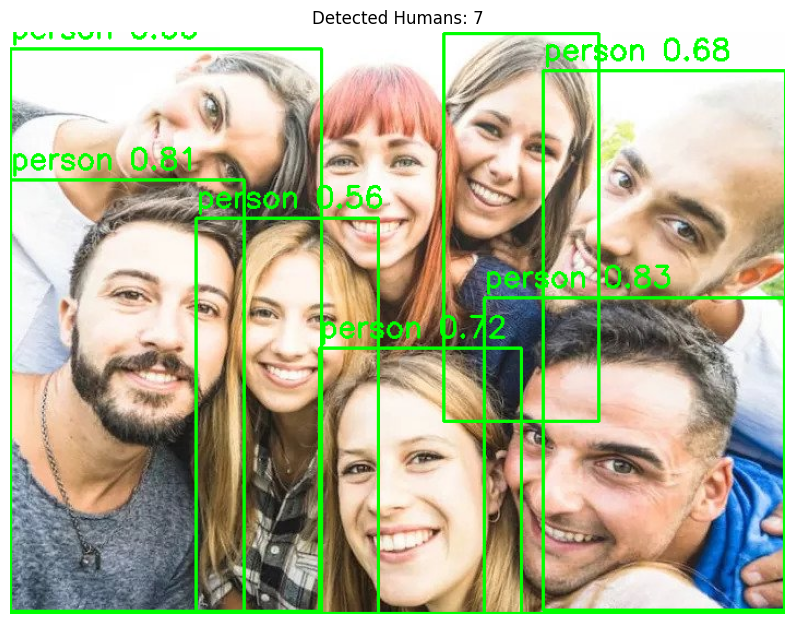

In [4]:
from ultralytics import YOLO

import cv2

import matplotlib.pyplot as plt
 

model = YOLO('yolov8n.pt')
 

image = cv2.imread('your_image1.jpg')

results = model.predict(image, conf=0.5)

names = model.names

human_count = 0

annotated_image = image.copy()
 
for r in results:

    for box in r.boxes:

        cls = int(box.cls[0])

        if names[cls] == 'person':

            human_count += 1

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green box

            label = f'{names[cls]} {box.conf[0]:.2f}'

            cv2.putText(annotated_image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

print(f"Number of humans detected: {human_count}")

annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))

plt.imshow(annotated_image_rgb)

plt.title(f"Detected Humans: {human_count}")

plt.axis('off')

plt.show()
 